## Import Library

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 Re-load and clean the source Excel data locally

In [2]:
print("🔄 Running pipeline: loading data...")
df = pd.read_excel('../data/Online_Retail.xlsx', engine='openpyxl')
df_clean = df.dropna(subset=['CustomerID'])
df_final = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)].copy()
df_final['TotalSum'] = df_final['Quantity'] * df_final['UnitPrice']
df_final['InvoiceDate'] = pd.to_datetime(df_final['InvoiceDate'])

# 📊 Re-aggregate into the baseline RFM metrics
snapshot_date = df_final['InvoiceDate'].max() + dt.timedelta(days=1)
rfm_table = df_final.groupby(['CustomerID']).agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalSum': 'sum'
})
rfm_table.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalSum': 'Monetary'}, inplace=True)
print("✅ Baseline RFM fields loaded safely!")

🔄 Running pipeline: loading data...
✅ Baseline RFM fields loaded safely!


# Part 3 👉 UNSUPERVISED MACHINE LEARNING (K-MEANS CLUSTERING)

## 🛡️ Isolate features for Machine Learning

In [3]:
data_features = rfm_table[['Recency', 'Frequency', 'Monetary']].copy()

#  Unskew the metrics using a Log Transformation(Since outliers like whales can warp K-means) 
data_log = np.log10(data_features)

# ⚖️ Normalize the features so they share an identical numeric scale
scaler = StandardScaler()
scaler.fit(data_log)
data_normalized = scaler.transform(data_log)

# Convert it back to a clean tracking DataFrame
df_normalized = pd.DataFrame(data_normalized, index=data_features.index, columns=data_features.columns)
print("✅ Data Log Transformed and Normalized for Machine Learning!")
df_normalized.head()

✅ Data Log Transformed and Normalized for Machine Learning!


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.409894,-2.775160,3.698719
12347.0,-2.146498,1.149549,1.410201
12348.0,0.383971,-0.185347,0.716419
12349.0,-0.574674,0.460579,0.698706
12350.0,1.374758,-0.638433,-0.617446


## Finding the Optimal Clusters (The Elbow Method)

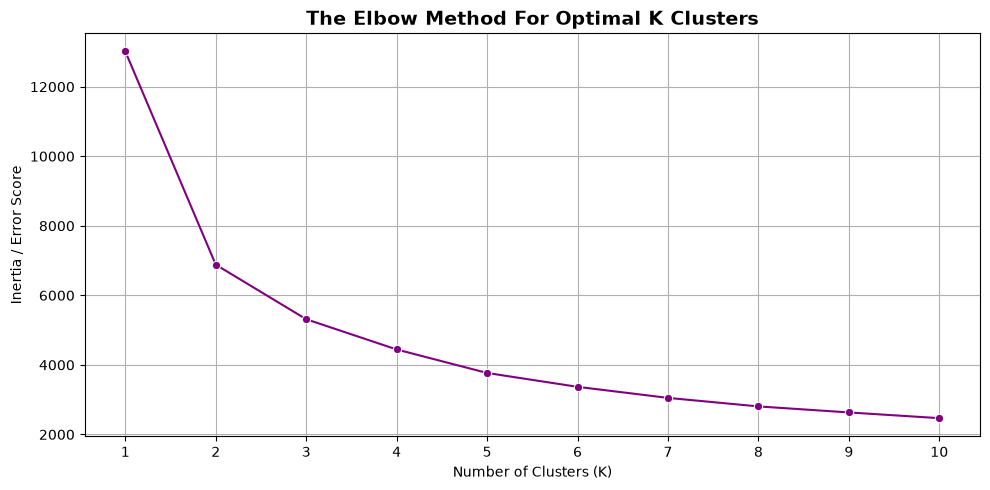

In [4]:
# Calculate error scores (inertia) for cluster sizes 1 through 10
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_normalized)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 5))
sns.lineplot(x=range(1, 11), y=inertia, marker='o', color='purple')
plt.title('The Elbow Method For Optimal K Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia / Error Score')
plt.xticks(range(1, 11))
plt.grid(True)

# Save the elbow plot image for GitHub
plt.tight_layout()
plt.savefig('../images/elbow_method_curve.png', dpi=300)
plt.show()

<div style="background-color: #444C38; color: #FFFFFF; padding: 15px; border-radius: 5px; font-size: 16px;">
    <p>
        Considering the line that drops dramatically from 1 to 2, and 2 to 3, but after 3, the line starts to flatten out into a gentle slope.
    </p>
    <p>
        This mathematically proves that grouping the e-commerce customers into 3 distinct clusters will provide the most accurate and efficient segmentation.
    </p>
   
</div>

## Trainning the Final K-Means Model

In [5]:
# 🤖 Initialize K-Means with our optimal cluster count discovered from the elbow curve (K=3)
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit the model onto our normalized data and extract the cluster tags
kmeans_model.fit(df_normalized)

# Assign the cluster labels back into our original rfm_table (adds values 0, 1, or 2)
rfm_table['K_Cluster'] = kmeans_model.labels_

print("🤖 Customer Segmentation Complete!")
# Let's inspect the average metrics for each of the 3 groups to see who they are
print(rfm_table.groupby('K_Cluster')[['Recency', 'Frequency', 'Monetary']].mean())


🤖 Customer Segmentation Complete!
              Recency   Frequency     Monetary
K_Cluster                                     
0          171.264648   14.907834   294.224826
1           13.106736  261.807254  6523.231420
2           69.376483   66.124595  1170.206080


<div style="background-color: #444C38; color: #FFFFFF; padding: 15px; border-radius: 5px; font-size: 16px;">
    <p>
        <span style="font-weight: bold;">Cluster 1 (The VIP Champions):</span> This group is incredible. They haven't ordered in only 13 days on average (Recency), buy very frequently (261 orders), and spend a massive average of 💸6,523!
    </p>
    <p>
         <span style="font-weight: bold;">Cluster 2 (The Active Casuals): </span>These are the reliable mid-tier shoppers. They bought roughly 69 days ago, make around 66 orders, and spend an average of 💸1,170.
    </p>
    <p>
        <span style="font-weight: bold;">Cluster 0 (The Churn/Lost Shoppers): </span>These users are fading fast. They haven't bought anything in 171 days on average, have placed only around 15 orders, and spend very little (💸294).
    </p>

</div>


## Export or save data

In [6]:
# 📂 Export the machine learning results to a clean CSV
rfm_table.to_csv('../data/final_customer_segments.csv', index=True)

print("💾 Data pipeline complete! 'final_customer_segments.csv' exported to data folder.")


💾 Data pipeline complete! 'final_customer_segments.csv' exported to data folder.
